# Bedrock Runtime vs Mantle Standard vs Mantle Reserved (RU) — Performance

Extends `mantle_gemma_perf.ipynb` with the Bedrock Mantle **Reservations preview**
(`Reservations-Preview-Intro.pdf`, `ru_assumptions.txt`) and adds a third arm: the classic
**Bedrock Runtime API** (boto3 `converse`/`converse_stream`, on-demand).

| model | runtime (boto3) | mantle standard | mantle reserved (RU) |
|---|---|---|---|
| `openai.gpt-oss-120b` | ✓ `openai.gpt-oss-120b-1:0` | ✓ `/v1` | ✓ (2 RU, $5.77/RU-hr) |
| `google.gemma-4-31b` | — not on Bedrock Runtime (gemma-3 only) | ✓ `/openai/v1` | attempted; RU spec unpublished — arm auto-skips if declined |

Measured per (model × tier × context size 256/1024/2048): **TTFT**, end-to-end **latency**
(p50/p90), **token generation speed**

---

## Reservations / Reservation Units (RU) — Bedrock Mantle Private Preview

Everything above exercises the **standard (on-demand) tier** and is unchanged. The sections
below add **reserved-tier** access on top of it.

A **Reservation Unit (RU)** is a model-specific throughput allotment measured in *blended*
tokens per minute: `blended_tpm = input_tpm + burndown_rate * output_tpm`. Reservations are
scoped to a **project + region + model** triple. Inference is routed to reserved capacity
simply by sending the `openai-project` header — no application routing logic. Traffic beyond
the reserved quota **spills over** to the standard tier and is flagged in a response header.

| Step | Call |
|---|---|
| 1 | `POST /v1/organization/projects` — create the project |
| 2 | (local) size the reservation — compute RUs needed |
| 3 | `POST /bedrock/v1/reservations` — create, then poll until `active` |
| 4 | `POST /v1/chat/completions` with `openai-project` — reserved-tier inference |
| 6 | `PUT /bedrock/v1/reservations/{id}` — scale RUs up/down |
| 7 | `DELETE /bedrock/v1/reservations/{id}` — cancel (billing continues until you do) |

**Assumptions** (`ru_assumptions.txt`)
1. RUs are allocated from **us-east-1**.
2. The existing Mantle bearer token (`BEDROCK_MANTLE_TOKEN`) is sufficient for RU access.
3. Multiple RUs may be created for a single project — start with **2**.

> **Billing:** a reservation bills from the moment it goes active (gpt-oss-120b:
> **$5.77/RU-hour**, first hour billed in full, per-minute prorating after that).
> Every mutating cell below is a **no-op until `CONFIRM_SPEND = True`**. Run the cancel
> cell when you are done.


In [1]:
# --- RU configuration + raw-HTTP helpers -----------------------------------
import json
import math
import os
import time
from concurrent.futures import ThreadPoolExecutor

import httpx
import requests

RU_REGION     = "us-east-1"          # assumption 1
RU_MODEL      = "openai.gpt-oss-120b"
RU_QUANTITY   = 2                    # assumption 3
RU_PROJECT_NAME = "mantle-ru-perf-0827"

CONFIRM_SPEND = True #False   # <-- flip to True to allow create / adjust / cancel

MANTLE_ENDPOINT = f"https://bedrock-mantle.{RU_REGION}.api.aws"
RU_TOKEN = os.environ["BEDROCK_MANTLE_TOKEN"]   # assumption 2

# Mantle's OpenAI-compatible surface is model-dependent: google.gemma-4-* live
# under /openai/v1, everything else (incl. gpt-oss) under /v1.
RU_BASE_PATH = "/openai/v1" if RU_MODEL.startswith("google.gemma-4") else "/v1"

# Filled in by the cells below.
PROJECT_ID     = os.environ.get("MANTLE_PROJECT_ID") or None
RESERVATION_ID = None

RESERVATION_HEADERS = (
    "x-amzn-usage-reservation-quota",            # blended TPM granted
    "x-amzn-usage-reservation-remaining-quota",   # blended TPM left this window
    "x-amzn-usage-reservation-spillover",         # "standard" => served on-demand
)

# --- Mantle API invocation log ----------------------------------------------
# Every Mantle API call this kernel makes lands in INVOCATION_LOG — raw
# mantle_request() calls below, and OpenAI-SDK calls via logging_http_client()
# (an httpx response hook). The "Invocation logs + CloudWatch logs" cells at the
# bottom of the notebook render it and save it into a markdown report.
INVOCATION_LOG = []

_REQUEST_ID_HEADERS = ("x-request-id", "x-amzn-requestid", "apigw-requestid")


def _handled_by(path, project_sent, res_hdrs):
    """Best-effort on-demand-pool vs reservation-unit attribution for one call.

    Only response headers are visible client-side, and the preview does not
    always return them on reserved-tier calls (observed in Step 4) — those rows
    read 'indeterminate'; the CloudWatch cells' BurnDownConsumed /
    SpillOverTokenCount metrics are the authoritative routing signal.
    """
    if not (path.endswith("/chat/completions") or path.endswith("/responses")):
        return ""                     # control plane — not routed to either pool
    if res_hdrs.get("x-amzn-usage-reservation-spillover") == "standard":
        return "on-demand (spillover)"
    if res_hdrs:
        return "reservation (RU)"
    return "indeterminate (no res headers)" if project_sent else "on-demand"


def _record_invocation(*, source, method, path, status, headers, project_sent,
                       latency_ms=None, usage=None, model=None):
    lower = {k.lower(): v for k, v in (headers or {}).items()}
    res_hdrs = {n: lower[n] for n in RESERVATION_HEADERS if n in lower}
    usage = usage if isinstance(usage, dict) else {}
    INVOCATION_LOG.append({
        "ts_utc": time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()),
        "epoch": time.time(),
        "source": source,             # raw = requests, sdk = OpenAI client
        "method": method,
        "path": path,
        "status": status,
        "request_id": next((lower[h] for h in _REQUEST_ID_HEADERS if h in lower), ""),
        "project": project_sent or "",
        "model": model or "",
        # chat/completions usage says prompt_/completion_tokens, Responses API
        # says input_/output_tokens — accept either.
        "in_tokens": usage.get("prompt_tokens", usage.get("input_tokens")),
        "out_tokens": usage.get("completion_tokens", usage.get("output_tokens")),
        "quota": res_hdrs.get("x-amzn-usage-reservation-quota"),
        "remaining_quota": res_hdrs.get("x-amzn-usage-reservation-remaining-quota"),
        "spillover": res_hdrs.get("x-amzn-usage-reservation-spillover"),
        "handled_by": _handled_by(path, project_sent, res_hdrs),
        "latency_ms": round(latency_ms, 1) if latency_ms is not None else None,
    })


_HTTPX_T0 = {}                        # id(request) -> perf_counter at send time


def _httpx_on_request(request):
    _HTTPX_T0[id(request)] = time.perf_counter()


def _httpx_on_response(response):
    """httpx response hook — fires when headers arrive; the body may still be
    streaming, so it must not be touched here. Consequences: no token usage for
    SDK calls, and latency_ms is time-to-headers, not end-to-end (the benchmark
    cells measure real TTFT/latency themselves)."""
    req = response.request
    t0 = _HTTPX_T0.pop(id(req), None)
    try:
        req_model = json.loads(req.content or b"{}").get("model")
    except Exception:
        req_model = None
    _record_invocation(
        source="sdk", method=req.method, path=req.url.path,
        status=response.status_code, headers=dict(response.headers),
        project_sent=req.headers.get("openai-project"),
        latency_ms=(time.perf_counter() - t0) * 1000 if t0 is not None else None,
        model=req_model,
    )


def logging_http_client(timeout=600):
    """httpx client for OpenAI(...) that records every call into INVOCATION_LOG."""
    return httpx.Client(timeout=timeout, event_hooks={
        "request": [_httpx_on_request], "response": [_httpx_on_response]})


def mantle_request(method, path, *, project=None, body=None, region=None, timeout=120):
    """Raw Mantle call. Returns (status_code, headers, parsed_body).

    region overrides RU_REGION for that one call (used by the discovery cell to
    sweep for reservations left running in other regions). Every call is also
    appended to INVOCATION_LOG.
    """
    endpoint = f"https://bedrock-mantle.{region}.api.aws" if region else MANTLE_ENDPOINT
    headers = {"Authorization": f"Bearer {RU_TOKEN}", "Content-Type": "application/json"}
    if project:
        headers["openai-project"] = project
    t0 = time.perf_counter()
    resp = requests.request(
        method, f"{endpoint}{path}", headers=headers, json=body, timeout=timeout
    )
    try:
        parsed = resp.json()
    except ValueError:
        parsed = resp.text
    _record_invocation(
        source="raw", method=method.upper(), path=path, status=resp.status_code,
        headers=dict(resp.headers), project_sent=project,
        latency_ms=(time.perf_counter() - t0) * 1000,
        usage=parsed.get("usage") if isinstance(parsed, dict) else None,
        model=body.get("model") if isinstance(body, dict) else None,
    )
    return resp.status_code, dict(resp.headers), parsed


def reservation_headers(headers):
    """Pull the x-amzn-usage-reservation-* headers out of a response (case-insensitive)."""
    lower = {k.lower(): v for k, v in headers.items()}
    return {name: lower[name] for name in RESERVATION_HEADERS if name in lower}


def res_project_id(res):
    """Bare proj_... id of the project that OWNS this reservation, or None.

    Two traps this exists to close:
      1. The API reports project_id as a full ARN
         (arn:aws:bedrock-mantle:<region>:<acct>:project/proj_xxx), but the
         openai-project header needs the bare id — so always strip it.
      2. Never take the project from an enclosing loop over list_projects():
         GET /bedrock/v1/reservations IGNORES openai-project and returns every
         reservation in the region, so that pairing is arbitrary. GET/DELETE on
         a single reservation DO enforce the header, so a mismatched pair 404s.
    """
    return (res.get("project_id") or "").rstrip("/").split("/")[-1] or None


def show(status, headers, body, *, max_chars=2000):
    print("HTTP", status)
    for k, v in reservation_headers(headers).items():
        print(f"  {k}: {v}")
    text = json.dumps(body, indent=2) if isinstance(body, (dict, list)) else str(body)
    print(text[:max_chars])


def cancel_reservation(reservation_id, *, project=None, region=None, verify=True):
    """Cancel a reservation so it stops billing. Returns True on success.

    Deliberately NOT gated by CONFIRM_SPEND: cancelling only ever saves money,
    and a kernel restart resets CONFIRM_SPEND to False — that must never leave
    you unable to tear down a reservation that is actively billing.
    """
    if not reservation_id:
        print("cancel_reservation: no reservation id given.")
        return False
    path = f"/bedrock/v1/reservations/{reservation_id}"
    status, headers, body = mantle_request(
        "DELETE", path, project=project or PROJECT_ID, region=region
    )
    print(f"DELETE {path} [{region or RU_REGION}] -> HTTP {status}")
    if status >= 300:
        show(status, headers, body, max_chars=400)
        return False
    if verify:
        vstatus, _, check = mantle_request(
            "GET", path, project=project or PROJECT_ID, region=region
        )
        res = check.get("reservation", check) if isinstance(check, dict) else {}
        print(f"  status now = {res.get('status') or f'HTTP {vstatus}'}"
              f"  (first hour billed in full; billing stops now)")
    return True


def require_spend(action):
    """Gate every billable / mutating call behind an explicit opt-in."""
    if not CONFIRM_SPEND:
        print(f"[skipped] {action}\n          set CONFIRM_SPEND = True to execute.")
        return False
    return True


print(f"endpoint : {MANTLE_ENDPOINT}")
print(f"model    : {RU_MODEL}  (inference path {RU_BASE_PATH})")
print(f"RUs      : {RU_QUANTITY}")
print(f"spend    : {'ENABLED' if CONFIRM_SPEND else 'blocked (CONFIRM_SPEND=False)'}")
print(f"invlog   : ON — every Mantle API call is recorded in INVOCATION_LOG "
      f"(report cells at the bottom)")

endpoint : https://bedrock-mantle.us-east-1.api.aws
model    : openai.gpt-oss-120b  (inference path /v1)
RUs      : 2
spend    : ENABLED
invlog   : ON — every Mantle API call is recorded in INVOCATION_LOG (report cells at the bottom)


/home/alfred/anaconda3/envs/vllm/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


### Step 1: project

Reservations are created *against a project*. This cell is idempotent and free — it reuses an
existing project with the same name rather than creating duplicates.


In [2]:
# --- Step 1: create (or reuse) the project ---------------------------------
status, _, body = mantle_request("GET", "/v1/organization/projects")
existing = {p["name"]: p["id"] for p in (body.get("data", []) if isinstance(body, dict) else [])}
print("HTTP", status, "existing projects:", existing or "(none)")

if RU_PROJECT_NAME in existing:
    PROJECT_ID = existing[RU_PROJECT_NAME]
    print(f"reusing project {RU_PROJECT_NAME} -> {PROJECT_ID}")
else:
    status, _, body = mantle_request(
        "POST",
        "/v1/organization/projects",
        body={
            "name": RU_PROJECT_NAME,
            "tags": {
                "Project": "MantleRUPreview",
                "Environment": "Test",
                "Owner": "TeamAlpha",
                "CostCenter": "21524",
            },
        },
    )
    show(status, {}, body)
    if status < 300:
        PROJECT_ID = body.get("id") or body.get("project", {}).get("id")
        print(f"created project -> {PROJECT_ID}")

print("PROJECT_ID =", PROJECT_ID)


HTTP 200 existing projects: {'default': 'default', 'mantle-ru-perf-0827': 'proj_yaio336tr2tbqkzifcnp'}
reusing project mantle-ru-perf-0827 -> proj_yaio336tr2tbqkzifcnp
PROJECT_ID = proj_yaio336tr2tbqkzifcnp


### Step 2: size the reservation

`blended_tpm_needed = avg_input_tpm + burndown_rate * avg_output_tpm`,
`rus_needed = ceil(blended_tpm_needed / tpm_per_ru)`.

Only gpt-oss-120b sizing is published in the preview doc; ask the Bedrock specialist team for
other models and add them to `RU_CATALOG`.


In [3]:
# --- Step 2: RU sizing calculator ------------------------------------------
RU_CATALOG = {
    # model: blended TPM per RU, burndown rate, USD per RU-hour
    "openai.gpt-oss-120b": {"tpm_per_ru": 641_000, "burndown_rate": 4, "usd_per_ru_hour": 5.77},
}


def size_reservation(model, avg_in_tokens, avg_out_tokens, requests_per_minute):
    """Return the RU count (and cost) needed for a traffic profile."""
    spec = RU_CATALOG[model]
    in_tpm = avg_in_tokens * requests_per_minute
    out_tpm = avg_out_tokens * requests_per_minute
    blended_tpm = in_tpm + spec["burndown_rate"] * out_tpm
    rus = math.ceil(blended_tpm / spec["tpm_per_ru"])
    return {
        "rpm": requests_per_minute,
        "in_tpm": in_tpm,
        "out_tpm": out_tpm,
        "blended_tpm": blended_tpm,
        "rus_needed": rus,
        "usd_per_hour": round(rus * spec["usd_per_ru_hour"], 2),
        "headroom_pct": round(100 * (1 - blended_tpm / (rus * spec["tpm_per_ru"])), 1),
    }


spec = RU_CATALOG[RU_MODEL]
print(f"{RU_MODEL}: {spec['tpm_per_ru']:,} blended TPM/RU, "
      f"burndown x{spec['burndown_rate']}, ${spec['usd_per_ru_hour']}/RU-hour\n")

# Candidate traffic profiles: (avg input tokens, avg output tokens, requests/minute)
PROFILES = [(1_000, 500, 60), (1_000, 500, 300), (4_000, 1_000, 120), (500, 2_000, 200)]

hdr = f"{'in_tok':>7} {'out_tok':>8} {'rpm':>5} {'blended_tpm':>13} {'RUs':>5} {'$/hour':>8} {'headroom':>9}"
print(hdr)
print("-" * len(hdr))
for avg_in, avg_out, rpm in PROFILES:
    r = size_reservation(RU_MODEL, avg_in, avg_out, rpm)
    print(f"{avg_in:>7} {avg_out:>8} {rpm:>5} {r['blended_tpm']:>13,} "
          f"{r['rus_needed']:>5} {r['usd_per_hour']:>8} {r['headroom_pct']:>8}%")

# Inverse view: what does the RU_QUANTITY we plan to buy actually buy us?
capacity = RU_QUANTITY * spec["tpm_per_ru"]
print(f"\n{RU_QUANTITY} RU(s) => {capacity:,} blended TPM "
      f"(${round(RU_QUANTITY * spec['usd_per_ru_hour'], 2)}/hour)")
for avg_in, avg_out in [(1_000, 500), (4_000, 1_000)]:
    per_req = avg_in + spec["burndown_rate"] * avg_out
    print(f"   ~{capacity // per_req:,} req/min at {avg_in} in / {avg_out} out tokens")


openai.gpt-oss-120b: 641,000 blended TPM/RU, burndown x4, $5.77/RU-hour

 in_tok  out_tok   rpm   blended_tpm   RUs   $/hour  headroom
-------------------------------------------------------------
   1000      500    60       180,000     1     5.77     71.9%
   1000      500   300       900,000     2    11.54     29.8%
   4000     1000   120       960,000     2    11.54     25.1%
    500     2000   200     1,700,000     3    17.31     11.6%

2 RU(s) => 1,282,000 blended TPM ($11.54/hour)
   ~427 req/min at 1000 in / 500 out tokens
   ~160 req/min at 4000 in / 1000 out tokens


### Step 3: create the reservation, then poll to `active`

`active` → usable. `pending` → capacity being allocated (best-effort, usually minutes; escalate
past 30 min). `declined` → no capacity in this region for this model; retry later or try
another region.

**This is the billable call.**

Step 3c is a **read-only discovery** cell: it sweeps every project in every listed region,
prints full detail for each reservation (units, status, capacity, estimated spend so far), and
adopts the first active/pending one into `RESERVATION_ID`. Run it after a kernel restart, or
whenever Step 6/7 says *no RESERVATION_ID*, or to confirm nothing is left billing.


In [4]:
# --- Step 3a: create the reservation (BILLABLE) ----------------------------
if PROJECT_ID and require_spend(f"POST /bedrock/v1/reservations  {RU_QUANTITY} RU x {RU_MODEL}"):
    status, headers, body = mantle_request(
        "POST",
        "/bedrock/v1/reservations",
        project=PROJECT_ID,
        body={
            "model": RU_MODEL,
            "reservation_units": {"unit": "model_units", "quantity": int(RU_QUANTITY)},
        },
    )
    show(status, headers, body)
    res = body.get("reservation", body) if isinstance(body, dict) else {}
    RESERVATION_ID = res.get("id")
    print("\nRESERVATION_ID =", RESERVATION_ID, "| status =", res.get("status"))
elif not PROJECT_ID:
    print("no PROJECT_ID — run the project cell first.")


HTTP 201
{
  "id": "res_fd9d02a0ccaa42ceba246a4979b9535e",
  "object": "reservation",
  "created_at": 1787868583,
  "last_updated_at": 1787868583,
  "project_id": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_yaio336tr2tbqkzifcnp",
  "model": "openai.gpt-oss-120b",
  "reservation_units": {
    "unit": "reservation_units",
    "quantity": 2
  },
  "status": "active"
}

RESERVATION_ID = res_fd9d02a0ccaa42ceba246a4979b9535e | status = active


In [5]:
# --- Step 3b: poll until active -------------------------------------------
def get_reservation(reservation_id):
    return mantle_request("GET", f"/bedrock/v1/reservations/{reservation_id}", project=PROJECT_ID)


def wait_active(reservation_id, timeout_s=1800, interval_s=15):
    """Poll a pending reservation. Returns the final reservation dict."""
    deadline = time.time() + timeout_s
    while True:
        status, _, body = get_reservation(reservation_id)
        res = body.get("reservation", body) if isinstance(body, dict) else {}
        state = str(res.get("status", "")).lower()
        print(f"  [{time.strftime('%H:%M:%S')}] HTTP {status} status={state or '?'} "
              f"{res.get('status_message', '')}")
        if state in ("active", "declined", "cancelled") or status >= 400:
            return res
        if time.time() >= deadline:
            print("  still pending past timeout — contact AWS Support if >30 min.")
            return res
        time.sleep(interval_s)


if RESERVATION_ID:
    reservation = wait_active(RESERVATION_ID)
    print("\nfinal:", json.dumps(reservation, indent=2))
else:
    print("no RESERVATION_ID in this kernel. Either:")
    print("  - run the discovery cell below (Step 3c) to find and adopt an existing one, or")
    print('  - set it by hand: RESERVATION_ID = "res_..."')


  [22:09:43] HTTP 200 status=active 

final: {
  "id": "res_fd9d02a0ccaa42ceba246a4979b9535e",
  "object": "reservation",
  "created_at": 1787868583,
  "last_updated_at": 1787868583,
  "project_id": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_yaio336tr2tbqkzifcnp",
  "model": "openai.gpt-oss-120b",
  "reservation_units": {
    "unit": "reservation_units",
    "quantity": 2
  },
  "status": "active"
}


In [6]:
# --- Step 3c: discover + inspect existing reservations --------------------
# Answers "what reservations do I actually have?" without needing the create
# cell to have run in this kernel. Sweeps every project in every listed region,
# prints full detail (incl. estimated spend so far), and adopts the first
# active/pending reservation into RESERVATION_ID / PROJECT_ID so Steps 6 and 7
# work. Read-only — safe to run any time, and the right first stop after a
# kernel restart or when you suspect something is still billing.
RU_DISCOVER_REGIONS = [RU_REGION, "us-east-2", "us-west-2"]


def list_projects(region=None):
    status, _, body = mantle_request("GET", "/v1/organization/projects", region=region)
    return body.get("data", []) if status < 300 and isinstance(body, dict) else []


def list_reservations(project_id=None, region=None):
    status, _, body = mantle_request(
        "GET", "/bedrock/v1/reservations", project=project_id, region=region
    )
    if status >= 300 or not isinstance(body, dict):
        return [], status
    return body.get("data", body.get("reservations", [])) or [], status


def describe_reservation(res, *, region="", project_name=""):
    """Print every field of a reservation, plus derived capacity and spend."""
    units = res.get("reservation_units") or {}
    qty, model = units.get("quantity"), res.get("model", "?")
    spec = RU_CATALOG.get(model)
    created = res.get("created_at")

    print(f"  id          : {res.get('id')}")
    print(f"  model       : {model}")
    print(f"  region      : {region or RU_REGION}")
    print(f"  project     : {res.get('project_id', '?')}"
          f"{f'  ({project_name})' if project_name else ''}")
    print(f"  units       : {qty} x {units.get('unit', '?')}")
    print(f"  status      : {res.get('status')}  {res.get('status_message', '')}".rstrip())
    if created:
        age_h = (time.time() - created) / 3600
        print(f"  created_at  : "
              f"{time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(created))}  "
              f"({age_h:.2f} h ago)")
    if spec and qty:
        n = int(qty)
        print(f"  capacity    : {n * spec['tpm_per_ru']:,} blended TPM "
              f"(burndown x{spec['burndown_rate']})")
        rate = n * spec["usd_per_ru_hour"]
        if created and str(res.get("status", "")).lower() in ("active", "pending"):
            # First hour is always billed in full, per-minute prorating after.
            print(f"  est. spend  : ${rate * max(1.0, age_h):,.2f} so far  (${rate:.2f}/hour)")
        else:
            print(f"  rate        : ${rate:.2f}/hour")
    else:
        print(f"  capacity    : unknown — add '{model}' to RU_CATALOG for sizing/cost")
    print(f"  raw         : {json.dumps(res)}")


# If you already know the id, inspect it directly (no sweep needed).
if RESERVATION_ID:
    status, _, body = mantle_request(
        "GET", f"/bedrock/v1/reservations/{RESERVATION_ID}", project=PROJECT_ID
    )
    print(f"GET /bedrock/v1/reservations/{RESERVATION_ID} -> HTTP {status}")
    if status < 300:
        describe_reservation(body.get("reservation", body) if isinstance(body, dict) else {})
    else:
        print(json.dumps(body, indent=2)[:500])
    print()

found = []
for region in RU_DISCOVER_REGIONS:
    projects = list_projects(region)
    by_id = {p["id"]: p for p in projects}
    print(f"[{region}] {len(projects)} project(s): "
          f"{[p.get('name') for p in projects] or '(none)'}")
    # ONE unscoped call. GET /bedrock/v1/reservations ignores openai-project and
    # returns every reservation in the region, so looping over projects here
    # listed the same reservations once per project (a cartesian product: "8
    # reservation(s) found" for 4 real ones) and mislabelled each with whichever
    # project the loop was on. Ownership comes from the reservation itself.
    items, status = list_reservations(None, region)
    if status >= 300:
        print(f"    list reservations: HTTP {status}")
        continue
    for res in items:
        owner_id = res_project_id(res)
        owner = by_id.get(owner_id)
        owner_name = owner.get("name") if owner else "NOT LISTED (archived/inaccessible)"
        print(f"\n  --- {owner_name} / {res.get('id')} ---")
        describe_reservation(res, region=region, project_name=owner_name)
        found.append({"region": region, "project_id": owner_id,
                      "project_name": owner_name, "listed": owner is not None,
                      "reservation": res})

print(f"\n{'=' * 70}")
if found:
    live = [f for f in found
            if str(f["reservation"].get("status", "")).lower() in ("active", "pending")]
    print(f"{len(found)} reservation(s) found, {len(live)} active/pending.")
    if live:
        # Preference order. Plain live[0] is the OLDEST reservation in the
        # account, which in practice is a long-forgotten orphan in an archived
        # project — adopting it overwrote the PROJECT_ID Step 1 had just set
        # correctly, and Step 4 then failed with "Project '...' is archived".
        pick = (next((f for f in live if f["reservation"]["id"] == RESERVATION_ID), None)
                or next((f for f in live if f["project_id"] == PROJECT_ID), None)
                or next((f for f in live if f["listed"]), None)
                or live[0])
        RESERVATION_ID = pick["reservation"]["id"]
        if pick["project_id"]:
            PROJECT_ID = pick["project_id"]   # bare proj_... id, never the ARN
        print(f"adopted -> RESERVATION_ID = {RESERVATION_ID}")
        print(f"           PROJECT_ID     = {PROJECT_ID}  ({pick['project_name']})")
        if not pick["listed"]:
            print("  WARNING: that project is not in the projects list (archived or "
                  "inaccessible). Reserved-tier calls will fail with "
                  "'archived and does not support mutating operations'.")
        orphans = [f for f in live if not f["listed"]]
        if orphans:
            print(f"\n  {len(orphans)} reservation(s) owned by unlistable projects. "
                  f"These ARE billing, and a sweep over list_projects() can never "
                  f"cancel them — pass the owner id below explicitly:")
            for f in orphans:
                print(f"    {f['region']} / {f['project_id']} / {f['reservation']['id']}"
                      f"  ({f['reservation'].get('status')})")
        if pick["region"] != RU_REGION:
            print(f"  NOTE: it lives in {pick['region']}, not RU_REGION={RU_REGION}. "
                  f"Set RU_REGION and re-run the config cell before Step 6/7.")
        print("  Steps 6 (adjust) and 7 (cancel) will now target it.")
else:
    print("No reservations exist in any listed region — nothing is billing.")
    print("Expected if the create cell (Step 3a) was skipped by CONFIRM_SPEND=False:")
    print("  that is exactly why Steps 6 and 7 report 'no RESERVATION_ID'.")
    print("To create one: set CONFIRM_SPEND = True, re-run the config cell, then Step 3a.")

GET /bedrock/v1/reservations/res_fd9d02a0ccaa42ceba246a4979b9535e -> HTTP 200
  id          : res_fd9d02a0ccaa42ceba246a4979b9535e
  model       : openai.gpt-oss-120b
  region      : us-east-1
  project     : arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_yaio336tr2tbqkzifcnp
  units       : 2 x reservation_units
  status      : active
  created_at  : 2026-08-27 22:09:43  (0.00 h ago)
  capacity    : 1,282,000 blended TPM (burndown x4)
  est. spend  : $11.54 so far  ($11.54/hour)
  raw         : {"id": "res_fd9d02a0ccaa42ceba246a4979b9535e", "object": "reservation", "created_at": 1787868583, "last_updated_at": 1787868583, "project_id": "arn:aws:bedrock-mantle:us-east-1:976939723775:project/proj_yaio336tr2tbqkzifcnp", "model": "openai.gpt-oss-120b", "reservation_units": {"unit": "reservation_units", "quantity": 2}, "status": "active"}

[us-east-1] 2 project(s): ['default', 'mantle-ru-perf-0827']

  --- mantle-ru-perf-0827 / res_0a7813d8b70940e481e08fb71ef104e3 ---
  id      

### Step 4: reserved-tier inference

Add the `openai-project` header and Bedrock matches the request to the project's active
reservation for that model. `service_tier: "auto"` lets it fall back to on-demand on overflow.
The response carries `x-amzn-usage-reservation-quota` / `-remaining-quota`, plus
`x-amzn-usage-reservation-spillover: standard` when the request was served on-demand instead.

> gpt-oss needs `max_tokens >= 256` to answer reliably on Mantle.


In [7]:
# --- Step 4a: raw HTTP, so the reservation headers are visible ------------
PAYLOAD = {
    "model": RU_MODEL,
    "service_tier": "auto",
    "max_tokens": 1024,
    "messages": [{"role": "user", "content": "Tell me a dad joke."}],
}

for label, project in (("standard tier", None), ("reserved tier", PROJECT_ID)):
    if label.startswith("reserved") and not PROJECT_ID:
        print("\n=== reserved tier: no PROJECT_ID, skipped ===")
        continue
    print(f"\n=== {label} ===")
    status, headers, body = mantle_request(
        "POST", f"{RU_BASE_PATH}/chat/completions", project=project, body=PAYLOAD
    )
    print("HTTP", status)
    hdrs = reservation_headers(headers)
    print("  reservation headers:", hdrs or "(none returned)")
    if isinstance(body, dict) and body.get("choices"):
        print("  usage:", body.get("usage"))
        print("  text :", body["choices"][0]["message"]["content"][:300])
    else:
        print(json.dumps(body, indent=2)[:800] if isinstance(body, dict) else str(body)[:800])



=== standard tier ===
HTTP 200
  reservation headers: (none returned)
  usage: {'completion_tokens': 54, 'prompt_tokens': 73, 'total_tokens': 127}
  text : Why did the scarecrow win an award?

Because he was outstanding in his **field**! 😄

=== reserved tier ===
HTTP 200
  reservation headers: (none returned)
  usage: {'completion_tokens': 49, 'prompt_tokens': 73, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 32}, 'total_tokens': 122}
  text : Why did the scarecrow become a successful motivational speaker?  

Because he was outstanding in his field! 🌾😄


In [8]:
# --- Step 4b: same thing through the OpenAI SDK ---------------------------
# default_headers puts openai-project on every request from this client, so the
# rest of your application code is unchanged. logging_http_client() (config
# cell) records every SDK call into INVOCATION_LOG for the log-report cells.
from openai import OpenAI
import pandas as pd

def ru_client(project=None):
    kwargs = {"default_headers": {"openai-project": project}} if project else {}
    return OpenAI(api_key=RU_TOKEN, base_url=f"{MANTLE_ENDPOINT}{RU_BASE_PATH}",
                  http_client=logging_http_client(), **kwargs)


standard_client = ru_client()
reserved_client = ru_client(PROJECT_ID) if PROJECT_ID else None

if reserved_client:
    # with_raw_response keeps the HTTP headers accessible alongside the parsed body.
    raw = reserved_client.chat.completions.with_raw_response.create(
        model=RU_MODEL,
        max_tokens=256,
        messages=[{"role": "user", "content": "Tell me a dad joke."}],
    )
    print("reservation headers:", reservation_headers(dict(raw.headers)) or "(none returned)")
    completion = raw.parse()
    print("usage :", completion.usage)
    print("text  :", completion.choices[0].message.content[:300])
else:
    print("no PROJECT_ID — run the project cell first.")

reservation headers: (none returned)
usage : CompletionUsage(completion_tokens=45, prompt_tokens=73, total_tokens=118, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cache_write_tokens=None, cached_tokens=32))
text  : Why did the scarecrow win an award?  

Because he was outstanding in his field! 🌾😁


## Reserved vs standard tier comparison

Same model, same prompts, same streaming path as the benchmark above — the only new dimension
is `tier` (`standard` = no `openai-project` header, `reserved` = with it). Two measurements:

1. **Latency profile** — TTFT / end-to-end latency / generation rate per (tier, scenario).
2. **Quota + spillover probe** — a concurrent burst of non-streaming requests, reading
   `x-amzn-usage-reservation-remaining-quota` and counting
   `x-amzn-usage-reservation-spillover: standard` responses. Push `RU_BURST_*` high enough to
   exceed `RU_QUANTITY * tpm_per_ru` blended TPM and spillover should appear.

The third cell is an **automatic teardown**: it cancels the reservation as soon as the two
measurement cells finish, so the RU bills for the shortest possible window. Cancelling is never
gated by `CONFIRM_SPEND` — a kernel restart resets that flag to `False`, and that must never
leave you unable to stop a reservation that is billing. Step 7 then sweeps every project and
region as a final safety net.


In [9]:
# --- Tier comparison 1/4: latency profile (streaming) --------------------
# gpt-oss does not stream on /v1/chat/completions via Mantle (404) — the
# Responses API does, same as the benchmark cell above.
import pandas as pd

RU_N_RUNS = 10
RU_SCENARIOS = [
    {"name": "short_256",   "max_tokens": 256,  "prompt": "Write one sentence about computing."},
    {"name": "medium_1024", "max_tokens": 1024, "prompt": (
        "Write a paragraph about the history of computing, covering early mechanical "
        "devices, the rise of digital computers, and the modern era.")},
]


def bench_tier(client, model, prompt, max_tokens):
    """One streamed Responses-API call -> timings + usage."""
    t0 = time.perf_counter()
    ttft = None
    in_tokens = out_tokens = 0
    stream = client.responses.create(
        model=model,
        input=[{"role": "user", "content": prompt}],
        max_output_tokens=max_tokens,
        stream=True,
    )
    for event in stream:
        et = getattr(event, "type", "")
        if ttft is None and et == "response.output_text.delta" and getattr(event, "delta", None):
            ttft = time.perf_counter() - t0
        if et == "response.completed":
            usage = getattr(getattr(event, "response", None), "usage", None)
            if usage:
                in_tokens = getattr(usage, "input_tokens", 0) or 0
                out_tokens = getattr(usage, "output_tokens", 0) or 0
    latency = time.perf_counter() - t0
    return {"ttft": ttft or 0.0, "latency": latency, "in_tokens": in_tokens, "out_tokens": out_tokens}


TIERS = [("standard", standard_client)]
if reserved_client:
    TIERS.append(("reserved", reserved_client))
else:
    print("reserved tier skipped — no PROJECT_ID / active reservation.\n")

ru_records = []
for tier, client in TIERS:
    for scen in RU_SCENARIOS:
        print(f"\n[{tier} | {scen['name']}] {RU_N_RUNS} runs...")
        for i in range(RU_N_RUNS):
            try:
                r = bench_tier(client, RU_MODEL, scen["prompt"], scen["max_tokens"])
            except Exception as e:
                print(f"  run {i+1:2d}: FAILED ({type(e).__name__}: {str(e)[:90]})")
                continue
            gen_time = max(r["latency"] - r["ttft"], 1e-9)
            rate = r["out_tokens"] / gen_time if r["out_tokens"] else 0.0
            ru_records.append({
                "tier": tier, "model": RU_MODEL, "scenario": scen["name"],
                "run": i + 1,
                "ttft_ms": r["ttft"] * 1000, "latency_ms": r["latency"] * 1000,
                "in_tokens": r["in_tokens"], "out_tokens": r["out_tokens"], "rate_tps": rate,
            })
            print(f"  run {i+1:2d}: TTFT={r['ttft']*1000:7.1f}ms  lat={r['latency']*1000:8.1f}ms  "
                  f"in={r['in_tokens']:5d}  out={r['out_tokens']:4d}  rate={rate:6.2f}t/s")

ru_df = pd.DataFrame(ru_records)
print(f"\nCollected {len(ru_df)} runs across {ru_df['tier'].nunique() if len(ru_df) else 0} tier(s).")
if len(ru_df):
    print("\nruns per group:")
    print(ru_df.groupby(["tier", "scenario"]).size().to_string())

# head(3) *per tier* — a plain .head() shows only the first 5 rows, which are
# all 'standard' because that tier runs first, and looks like reserved is missing.
ru_df.groupby("tier").head(3)



[standard | short_256] 10 runs...
  run  1: TTFT=  970.3ms  lat=  1098.3ms  in=   73  out=  59  rate=460.87t/s
  run  2: TTFT=  697.5ms  lat=   699.4ms  in=   73  out=  82  rate=42753.47t/s
  run  3: TTFT=  584.3ms  lat=   589.9ms  in=   73  out=  61  rate=10749.94t/s
  run  4: TTFT=  606.4ms  lat=   612.6ms  in=   73  out=  61  rate=9761.40t/s
  run  5: TTFT=  700.4ms  lat=   707.4ms  in=   73  out=  73  rate=10535.12t/s
  run  6: TTFT=  757.2ms  lat=   763.2ms  in=   73  out=  71  rate=11736.24t/s
  run  7: TTFT=  822.3ms  lat=   823.9ms  in=   73  out=  76  rate=46870.51t/s
  run  8: TTFT=  454.9ms  lat=   460.7ms  in=   73  out=  51  rate=8866.71t/s
  run  9: TTFT=  826.1ms  lat=   832.7ms  in=   73  out=  72  rate=10921.60t/s
  run 10: TTFT=  699.3ms  lat=   705.9ms  in=   73  out=  80  rate=12117.93t/s

[standard | medium_1024] 10 runs...
  run  1: TTFT= 1058.9ms  lat=  2358.3ms  in=   92  out= 333  rate=256.28t/s
  run  2: TTFT= 1466.9ms  lat=  2935.1ms  in=   92  out= 374  rat

,tier,model,scenario,run,ttft_ms,latency_ms,in_tokens,out_tokens,rate_tps
0,standard,openai.gpt-oss-120b,short_256,1,970.281832,1098.300777,73,59,460.869286
1,standard,openai.gpt-oss-120b,short_256,2,697.479557,699.397530,73,82,42753.465835
2,standard,openai.gpt-oss-120b,short_256,3,584.264010,589.938462,73,61,10749.937511
20,reserved,openai.gpt-oss-120b,short_256,1,584.455468,592.229597,73,63,8103.801193
21,reserved,openai.gpt-oss-120b,short_256,2,402.567569,404.155836,73,76,47850.916404
22,reserved,openai.gpt-oss-120b,short_256,3,481.945977,486.730687,73,71,14838.932670


In [10]:
# --- Tier comparison 2/4: quota + spillover probe -----------------------
# Concurrent non-streaming burst; every response is inspected for the
# reservation headers. Raise the knobs until blended TPM > reserved capacity.
RU_BURST_REQUESTS   = 20
RU_BURST_CONCURRENCY = 5
RU_BURST_MAX_TOKENS  = 512

BURST_PROMPT = "Summarize the history of computing in three sentences."


def one_burst_request(project):
    status, headers, body = mantle_request(
        "POST",
        f"{RU_BASE_PATH}/chat/completions",
        project=project,
        body={
            "model": RU_MODEL,
            "service_tier": "auto",
            "max_tokens": RU_BURST_MAX_TOKENS,
            "messages": [{"role": "user", "content": BURST_PROMPT}],
        },
    )
    usage = body.get("usage", {}) if isinstance(body, dict) else {}
    hdrs = reservation_headers(headers)
    return {
        "status": status,
        "in_tokens": usage.get("prompt_tokens", 0),
        "out_tokens": usage.get("completion_tokens", 0),
        "quota": hdrs.get("x-amzn-usage-reservation-quota"),
        "remaining": hdrs.get("x-amzn-usage-reservation-remaining-quota"),
        "spillover": hdrs.get("x-amzn-usage-reservation-spillover"),
    }


burst_df = pd.DataFrame()
if reserved_client:
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=RU_BURST_CONCURRENCY) as pool:
        burst = list(pool.map(lambda _: one_burst_request(PROJECT_ID), range(RU_BURST_REQUESTS)))
    elapsed = time.perf_counter() - t0
    burst_df = pd.DataFrame(burst)

    ok = burst_df[burst_df["status"] < 300]
    burndown = RU_CATALOG[RU_MODEL]["burndown_rate"]
    blended = int(ok["in_tokens"].sum() + burndown * ok["out_tokens"].sum())
    spill = int((burst_df["spillover"].fillna("") == "standard").sum())

    print(f"{len(ok)}/{len(burst_df)} succeeded in {elapsed:.1f}s "
          f"({len(ok)/max(elapsed,1e-9)*60:.0f} req/min)")
    print(f"blended tokens consumed : {blended:,} "
          f"(={blended/max(elapsed,1e-9)*60:,.0f} blended TPM)")
    print(f"reserved capacity       : {RU_QUANTITY * RU_CATALOG[RU_MODEL]['tpm_per_ru']:,} blended TPM")
    print(f"spillover responses     : {spill}/{len(burst_df)}")
    print(f"quota header            : {burst_df['quota'].dropna().unique()[:3]}")
    rem = pd.to_numeric(burst_df["remaining"], errors="coerce").dropna()
    if len(rem):
        print(f"remaining quota         : {rem.max():,.0f} -> {rem.min():,.0f}")
    burst_df.head()
else:
    print("no active reservation — skipped.")


20/20 succeeded in 7.3s (164 req/min)
blended tokens consumed : 21,064 (=172,346 blended TPM)
reserved capacity       : 1,282,000 blended TPM
spillover responses     : 0/20
quota header            : []


In [11]:
# --- Tier comparison 3/4: TEARDOWN — cancel the reservation --------------
# Runs immediately after the two measurement cells so the reservation bills for
# the shortest possible window. The plotting cell that follows only touches
# ru_df, so nothing downstream needs the reservation alive.
#
# Not gated by CONFIRM_SPEND (cancelling saves money) and idempotent — safe to
# re-run, and safe when nothing exists. Set RU_AUTO_CANCEL=False only if you
# deliberately want to keep the capacity for more runs, and remember it bills
# until Step 7.
RU_AUTO_CANCEL = True

if not RU_AUTO_CANCEL:
    print("RU_AUTO_CANCEL=False — reservation left ACTIVE and STILL BILLING.")
    print("Run the Step 7 cell when you are done.")
else:
    targets = []
    if RESERVATION_ID:
        targets.append((RESERVATION_ID, PROJECT_ID, RU_REGION))
    # Also sweep RU_REGION, so a reservation made in an earlier kernel (where
    # RESERVATION_ID is now lost) still gets torn down.
    # One unscoped list, and pair each reservation with the project that OWNS it.
    # Iterating list_projects() and passing proj["id"] produced mismatched pairs
    # (the collection endpoint ignores openai-project, DELETE enforces it), so
    # every cancel returned HTTP 404 while reporting "STILL BILLING".
    items, _ = list_reservations(None, RU_REGION)
    for res in items:
        if str(res.get("status", "")).lower() in ("active", "pending"):
            if not any(t[0] == res["id"] for t in targets):
                targets.append((res["id"], res_project_id(res), RU_REGION))

    if not targets:
        print(f"nothing to cancel in {RU_REGION} — no active/pending reservation.")
    for rid, pid, region in targets:
        cancel_reservation(rid, project=pid, region=region)
    RESERVATION_ID = None
    print("\nRESERVATION_ID cleared. Step 7 below is the final safety net.")

DELETE /bedrock/v1/reservations/res_fd9d02a0ccaa42ceba246a4979b9535e [us-east-1] -> HTTP 200
  status now = cancelled  (first hour billed in full; billing stops now)

RESERVATION_ID cleared. Step 7 below is the final safety net.


    tier    scenario  n  ttft_mean_ms  ttft_std_ms  lat_mean_ms  lat_std_ms  rate_mean_tps  rate_std_tps  out_tokens_mean
reserved medium_1024 10         629.7         86.0       1359.2       807.5          674.1         356.9            273.0
reserved   short_256 10         531.4        214.5        537.3       215.0        18136.8       16696.4             71.6
standard medium_1024 10        1289.8        663.1       2826.8       806.9          216.6          53.5            310.3
standard   short_256 10         711.9        144.5        729.4       171.3        16477.4       15326.8             68.6

reserved vs standard (negative = reserved faster / positive rate = better):
  ttft_mean_ms   medium_1024     -660.1 ( -51.2%)
  ttft_mean_ms   short_256       -180.5 ( -25.4%)
  lat_mean_ms    medium_1024    -1467.6 ( -51.9%)
  lat_mean_ms    short_256       -192.1 ( -26.3%)
  rate_mean_tps  medium_1024     +457.5 (+211.2%)
  rate_mean_tps  short_256      +1659.4 ( +10.1%)


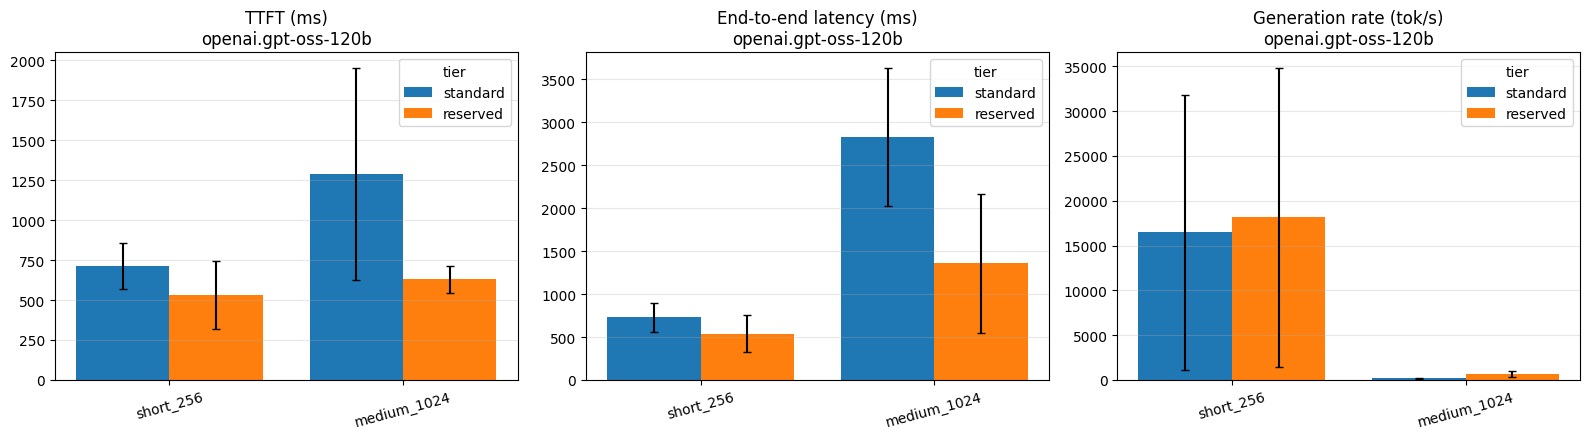

In [12]:
# --- Tier comparison 4/4: aggregate + plot ------------------------------
import matplotlib.pyplot as plt

if len(ru_df) == 0:
    print("ru_df is empty — did the tier benchmark cell run?")
else:
    ru_summary = (
        ru_df.groupby(["tier", "scenario"])
             .agg(n=("run", "count"),
                  ttft_mean_ms=("ttft_ms", "mean"),      ttft_std_ms=("ttft_ms", "std"),
                  lat_mean_ms=("latency_ms", "mean"),    lat_std_ms=("latency_ms", "std"),
                  rate_mean_tps=("rate_tps", "mean"),    rate_std_tps=("rate_tps", "std"),
                  out_tokens_mean=("out_tokens", "mean"))
             .round(1)
             .reset_index()
    )
    print(ru_summary.to_string(index=False))

    # Reserved vs standard delta per scenario.
    tiers = list(ru_df["tier"].unique())
    if len(tiers) == 2:
        pivot = ru_summary.pivot(index="scenario", columns="tier",
                                 values=["ttft_mean_ms", "lat_mean_ms", "rate_mean_tps"])
        print("\nreserved vs standard (negative = reserved faster / positive rate = better):")
        for metric in ("ttft_mean_ms", "lat_mean_ms", "rate_mean_tps"):
            delta = pivot[metric]["reserved"] - pivot[metric]["standard"]
            pct = 100 * delta / pivot[metric]["standard"]
            for scen in delta.index:
                print(f"  {metric:<14} {scen:<12} {delta[scen]:+9.1f} ({pct[scen]:+6.1f}%)")

    metrics = [("ttft_ms", "TTFT (ms)"), ("latency_ms", "End-to-end latency (ms)"),
               ("rate_tps", "Generation rate (tok/s)")]
    scenarios = list(ru_df["scenario"].unique())
    x = range(len(scenarios))
    width = 0.8 / max(len(tiers), 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, (col, title) in zip(axes, metrics):
        for j, tier in enumerate(tiers):
            sub = ru_df[ru_df["tier"] == tier].groupby("scenario")[col]
            means = [sub.mean().get(s, 0) for s in scenarios]
            errs = [sub.std().get(s, 0) for s in scenarios]
            ax.bar([i + j * width for i in x], means, width, yerr=errs, capsize=3, label=tier)
        ax.set_xticks([i + width * (len(tiers) - 1) / 2 for i in x])
        ax.set_xticklabels(scenarios, rotation=15)
        ax.set_title(f"{title}\n{RU_MODEL}")
        ax.legend(title="tier")
        ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


###  On-demand (default tier) TPM ceiling — gpt-oss-120b ONLY 

Measures the highest sustained tokens-per-minute the STANDARD on-demand tier
delivers *without throttling or queuing*, across the same three window sizes
the benchmark cells above use (short_256 / medium_1024 / long_2048).

 "gpt-oss-120b only": exactly one model, no sweep (contrast the benchmark cell
   above, which walks five). TPM_MODEL is pinned to the literal below rather
   than read from RU_MODEL, so retargeting the config cell — which supports
   other models, hence its google.gemma-4 path branch — cannot silently point
   this measurement at something else. TPM_BASE_PATH is gpt-oss's route.

In [13]:
#   So nothing can be matched to a reservation. The warmup call below asserts
#   this by showing that no x-amzn-usage-reservation-* headers come back.
# "without throttling": the client is built with max_retries=0 — the SDK default
#   of 2 would silently retry a 429 with backoff, which is precisely the
#   client-side throttling this measurement must not contain. There is no rate
#   limiter and no retry/backoff queue anywhere in the harness.
# "without queuing": queuing is detected rather than tolerated. A step whose
#   median TTFT inflates past TPM_QUEUE_FACTOR x the concurrency-1 baseline is
#   server-side queued, so it does not count toward the ceiling.
#
# Per window size, concurrency ramps up until a step throttles, errors or queues;
# the ceiling is the best TPM among the steps that stayed clean. Runtime scales
# with the ramp — worst case sum(TPM_CONCURRENCY_STEPS) * TPM_REQS_PER_WORKER
# requests per window, so lower TPM_REQS_PER_WORKER for a quick pass.

import statistics
import time
from concurrent.futures import ThreadPoolExecutor

import openai
import pandas as pd
from openai import OpenAI

TPM_MODEL             = "openai.gpt-oss-120b"   # pinned; deliberately not RU_MODEL
TPM_BASE_PATH         = "/v1"                   # gpt-oss's OpenAI-compatible route
TPM_CONCURRENCY_STEPS = [1, 2, 4, 8, 16, 32]
TPM_REQS_PER_WORKER   = 3      # requests per worker at each step (>=2 for steady state)
TPM_QUEUE_FACTOR      = 2.0    # median TTFT > factor x baseline => server-side queuing
TPM_BURNDOWN          = RU_CATALOG[TPM_MODEL]["burndown_rate"]

_TPM_LONG_BLOCK = "REFERENCE CONTEXT for throughput measurement. " * 250

TPM_WINDOWS = [
    {"name": "short_256", "max_tokens": 256,
     "prompt": "Write one sentence about computing."},
    {"name": "medium_1024", "max_tokens": 1024,
     "prompt": ("Write a paragraph about the history of computing, covering early "
                "mechanical devices, the rise of digital computers, and the modern era.")},
    {"name": "long_2048", "max_tokens": 2048,
     "prompt": (_TPM_LONG_BLOCK + "\n\nBased on the reference context above, write a "
                "comprehensive paragraph about the history of computing.")},
]

tpm_client = OpenAI(
    api_key=RU_TOKEN,
    base_url=f"{MANTLE_ENDPOINT}{TPM_BASE_PATH}",
    max_retries=0,   # do not retry 429s — see header comment
    timeout=600,
    http_client=logging_http_client(),   # INVOCATION_LOG capture (config cell)
)

# Warmup on the same path, and proof we are on the on-demand tier.
_st, _hdrs, _ = mantle_request(
    "POST", f"{TPM_BASE_PATH}/chat/completions",
    body={"model": TPM_MODEL, "max_tokens": 16,
          "messages": [{"role": "user", "content": "warmup"}]},
)
print(f"warmup HTTP {_st}  reservation headers: "
      f"{reservation_headers(_hdrs) or '(none -> on-demand / default tier)'}")


def tpm_request(window, nonce):
    """One streamed Responses-API call on the on-demand tier.

    gpt-oss does not stream on /v1/chat/completions via Mantle (404); the
    Responses API does, same as the benchmark cells above. The nonce keeps every
    prompt unique so prompt-cache hits cannot inflate the measured input TPM.
    Throttling surfaces as status "throttled" (429); 5xx overload lands in
    "error:<code>".
    """
    t0 = time.perf_counter()
    ttft = None
    in_tokens = out_tokens = 0
    try:
        stream = tpm_client.responses.create(
            model=TPM_MODEL,
            input=[{"role": "user", "content": f"[req {nonce}] {window['prompt']}"}],
            max_output_tokens=window["max_tokens"],
            stream=True,
        )
        for event in stream:
            et = getattr(event, "type", "")
            if ttft is None and et == "response.output_text.delta" and getattr(event, "delta", None):
                ttft = time.perf_counter() - t0
            if et == "response.completed":
                usage = getattr(getattr(event, "response", None), "usage", None)
                if usage:
                    in_tokens = getattr(usage, "input_tokens", 0) or 0
                    out_tokens = getattr(usage, "output_tokens", 0) or 0
    except openai.RateLimitError:
        return {"ttft": None, "latency": time.perf_counter() - t0,
                "in_tokens": 0, "out_tokens": 0, "status": "throttled"}
    except openai.APIStatusError as e:
        return {"ttft": None, "latency": time.perf_counter() - t0,
                "in_tokens": 0, "out_tokens": 0, "status": f"error:{e.status_code}"}
    except Exception as e:
        return {"ttft": None, "latency": time.perf_counter() - t0,
                "in_tokens": 0, "out_tokens": 0, "status": f"error:{type(e).__name__}"}
    return {"ttft": ttft, "latency": time.perf_counter() - t0,
            "in_tokens": in_tokens, "out_tokens": out_tokens, "status": "ok"}


tpm_records, tpm_ceilings = [], []

for w in TPM_WINDOWS:
    print(f"\n=== window={w['name']}  max_tokens={w['max_tokens']}  "
          f"{TPM_MODEL} @ {RU_REGION}  on-demand/default ===")
    baseline_ttft, clean_steps, broke_at = None, [], None

    for conc in TPM_CONCURRENCY_STEPS:
        n_req = conc * TPM_REQS_PER_WORKER
        t0 = time.perf_counter()
        with ThreadPoolExecutor(max_workers=conc) as pool:
            results = list(pool.map(
                lambda k: tpm_request(w, f"{w['name']}-c{conc}-{k}"), range(n_req)
            ))
        elapsed = max(time.perf_counter() - t0, 1e-9)

        ok      = [r for r in results if r["status"] == "ok"]
        n_429   = sum(1 for r in results if r["status"] == "throttled")
        n_err   = sum(1 for r in results if r["status"].startswith("error:"))
        in_tok  = sum(r["in_tokens"] for r in ok)
        out_tok = sum(r["out_tokens"] for r in ok)
        ttfts   = [r["ttft"] for r in ok if r["ttft"] is not None]
        med_ttft = statistics.median(ttfts) if ttfts else float("nan")

        # TPM over the step's wall clock — the whole step is the measurement window.
        total_tpm   = (in_tok + out_tok) / elapsed * 60
        out_tpm     = out_tok / elapsed * 60
        blended_tpm = (in_tok + TPM_BURNDOWN * out_tok) / elapsed * 60

        if baseline_ttft is None and ttfts:
            baseline_ttft = med_ttft
        ttft_ratio = med_ttft / baseline_ttft if baseline_ttft else float("nan")
        queued = bool(baseline_ttft) and ttft_ratio > TPM_QUEUE_FACTOR
        clean  = n_429 == 0 and n_err == 0 and not queued

        verdict = "ok" if clean else ",".join(
            s for s, flag in (("THROTTLED", n_429), ("ERRORS", n_err), ("QUEUED", queued)) if flag
        )
        print(f"  conc={conc:<3d} req={n_req:<4d} ok={len(ok):<4d} 429={n_429:<3d} "
              f"err={n_err:<3d} {elapsed:6.1f}s  TPM={total_tpm:>9,.0f}  "
              f"outTPM={out_tpm:>8,.0f}  blended={blended_tpm:>10,.0f}  "
              f"ttft={med_ttft * 1000:>7.0f}ms x{ttft_ratio:>4.2f}  {verdict}")

        step = {
            "window": w["name"], "max_tokens": w["max_tokens"], "concurrency": conc,
            "requests": n_req, "ok": len(ok), "throttled_429": n_429, "errors": n_err,
            "elapsed_s": round(elapsed, 2), "in_tokens": in_tok, "out_tokens": out_tok,
            "total_tpm": total_tpm, "out_tpm": out_tpm, "blended_tpm": blended_tpm,
            "ttft_med_ms": med_ttft * 1000, "ttft_ratio": ttft_ratio,
            "queued": queued, "clean": clean,
        }
        tpm_records.append(step)

        if clean:
            clean_steps.append(step)
        else:
            broke_at = conc
            break   # stop the ramp at the first dirty step — no point paying for more

    if clean_steps:
        best = max(clean_steps, key=lambda s: s["total_tpm"])
        tail = (f"broke at conc={broke_at}" if broke_at
                else "never broke — raise TPM_CONCURRENCY_STEPS to find the real ceiling")
        print(f"  -> clean TPM ceiling = {best['total_tpm']:,.0f} total "
              f"({best['out_tpm']:,.0f} output, {best['blended_tpm']:,.0f} blended) "
              f"at conc={best['concurrency']};  {tail}")
        tpm_ceilings.append({
            "window": w["name"], "max_tokens": w["max_tokens"],
            "clean_conc": best["concurrency"], "broke_at_conc": broke_at,
            "total_tpm": round(best["total_tpm"]), "out_tpm": round(best["out_tpm"]),
            "blended_tpm": round(best["blended_tpm"]),
            "ttft_med_ms": round(best["ttft_med_ms"], 1),
        })
    else:
        print("  -> no clean step: even conc=1 throttled or errored (see the row above)")

tpm_df = pd.DataFrame(tpm_records)
tpm_ceiling_df = pd.DataFrame(tpm_ceilings)

print("\n" + "=" * 96)
print(f"On-demand (default tier) TPM ceiling — {TPM_MODEL} @ {RU_REGION}")
print("no openai-project header, no service_tier, max_retries=0, no client-side rate limiter/queue")
print("=" * 96)
if len(tpm_ceiling_df):
    print(tpm_ceiling_df.to_string(index=False))
    _cap = RU_CATALOG[TPM_MODEL]["tpm_per_ru"]
    _best_blended = tpm_ceiling_df["blended_tpm"].max()
    print(f"\nreserved-tier reference: 1 RU = {_cap:,} blended TPM.  "
          f"best clean on-demand blended = {_best_blended:,} "
          f"({_best_blended / _cap:.2f} RU-equivalent)")
else:
    print("no clean measurements collected.")
tpm_df

warmup HTTP 200  reservation headers: (none -> on-demand / default tier)

=== window=short_256  max_tokens=256  openai.gpt-oss-120b @ us-east-1  on-demand/default ===
  conc=1   req=3    ok=3    429=0   err=0      1.9s  TPM=   14,767  outTPM=   6,860  blended=    35,346  ttft=    602ms x1.00  ok
  conc=2   req=6    ok=6    429=0   err=0      2.6s  TPM=   23,788  outTPM=  12,408  blended=    61,013  ttft=    736ms x1.22  ok
  conc=4   req=12   ok=12   429=0   err=0      3.2s  TPM=   40,034  outTPM=  21,410  blended=   104,265  ttft=    837ms x1.39  ok
  conc=8   req=24   ok=24   429=0   err=0      3.5s  TPM=   85,079  outTPM=  50,737  blended=   237,292  ttft=    969ms x1.61  ok
  conc=16  req=48   ok=48   429=0   err=0      4.2s  TPM=  139,155  outTPM=  82,694  blended=   387,235  ttft=    825ms x1.37  ok
  conc=32  req=96   ok=96   429=0   err=0      6.9s  TPM=  175,158  outTPM= 106,220  blended=   493,817  ttft=    930ms x1.55  ok
  -> clean TPM ceiling = 175,158 total (106,220 outpu

,window,max_tokens,concurrency,requests,ok,throttled_429,errors,elapsed_s,in_tokens,out_tokens,total_tpm,out_tpm,blended_tpm,ttft_med_ms,ttft_ratio,queued,clean
0,short_256,256,1,3,3,0,0,1.89,249,216,1.476706e+04,6859.535701,3.534566e+04,601.561800,1.000000,False,True
1,short_256,256,2,6,6,0,0,2.63,498,543,2.378812e+04,12408.210364,6.101275e+04,736.289762,1.223964,False,True
2,short_256,256,4,12,12,0,0,3.21,996,1145,4.003420e+04,21410.163003,1.042647e+05,836.550185,1.390630,False,True
3,short_256,256,8,24,24,0,0,3.48,1992,2943,8.507949e+04,50737.373185,2.372916e+05,969.039654,1.610873,False,True
4,short_256,256,16,48,48,0,0,4.23,3984,5835,1.391547e+05,82693.511965,3.872352e+05,825.247727,1.371842,False,True
5,short_256,256,32,96,96,0,0,6.93,7968,12277,1.751583e+05,106219.728389,4.938175e+05,929.724343,1.545518,False,True
6,medium_1024,1024,1,3,3,0,0,8.42,309,1044,9.642099e+03,7440.023433,3.196217e+04,980.593797,1.000000,False,True
7,medium_1024,1024,2,6,6,0,0,7.41,618,1990,2.112915e+04,16122.316677,6.949610e+04,741.940878,0.756624,False,True
8,medium_1024,1024,4,12,12,0,0,8.53,1236,3765,3.519163e+04,26493.995053,1.146736e+05,902.634090,0.920497,False,True
9,medium_1024,1024,8,24,24,0,0,8.78,2472,8103,7.230370e+04,55402.065358,2.385099e+05,942.913722,0.961574,False,True


### Step 6: adjust the reservation

Changes take effect immediately — no cooldown, no re-commitment. Drive this from the
`EquivalentReservationUnits` CloudWatch metric (namespace `AWS/BedrockMantle`, dimensions
model ID + project ID) over a multi-day window: sustained spillover above ~5% means scale up,
consistently below 50% of purchased RUs means scale down.

> The preview doc writes the update/cancel path as `/bedrock/v1/$RESERVATIONS_ID`, dropping the
> `reservations` segment used by POST and GET. Assumed to be a typo — the cells below use
> `/bedrock/v1/reservations/{id}`. If you get a 404, try the doc's literal path.


In [14]:
# --- Step 6: scale the reservation up/down (BILLABLE) --------------------
RU_NEW_QUANTITY = 2

if RESERVATION_ID and require_spend(
    f"PUT /bedrock/v1/reservations/{RESERVATION_ID}  -> {RU_NEW_QUANTITY} RU"
):
    status, headers, body = mantle_request(
        "PUT",
        f"/bedrock/v1/reservations/{RESERVATION_ID}",
        project=PROJECT_ID,
        body={"reservation_units": {"unit": "model_units", "quantity": int(RU_NEW_QUANTITY)}},
    )
    show(status, headers, body)
    if status < 300:
        RU_QUANTITY = RU_NEW_QUANTITY
elif not RESERVATION_ID:
    print("no RESERVATION_ID in this kernel — run the discovery cell (Step 3c) to find and\n"
          "adopt an existing reservation, or create one via Step 3a.")


no RESERVATION_ID in this kernel — run the discovery cell (Step 3c) to find and
adopt an existing reservation, or create one via Step 3a.


### Step 7: cancel — final safety net

**Billing continues until you cancel.** The first hour is always billed in full; after that it
stops immediately. The perf-test teardown cell already cancels, so this normally reports
*CLEAN*. It sweeps every project in every region in `RU_DISCOVER_REGIONS` and cancels anything
still active or pending — run it last, every session.


In [15]:
# --- Step 7: cancel — final safety net -----------------------------------
# Cancels the tracked reservation, then sweeps EVERY project in EVERY region in
# RU_DISCOVER_REGIONS and cancels anything still active/pending. Not gated by
# CONFIRM_SPEND: teardown must always be possible, including after a kernel
# restart. Run this last, every session.
RU_CANCEL_EVERYTHING = True

if RESERVATION_ID:
    cancel_reservation(RESERVATION_ID)
    RESERVATION_ID = None
else:
    print("no RESERVATION_ID tracked in this kernel — sweeping for leftovers instead.")

# One unscoped list per region, each reservation paired with its OWNING project
# (see res_project_id). The previous project-loop pairing 404'd on every cancel.
leftovers = []
for region in RU_DISCOVER_REGIONS:
    names = {p["id"]: p.get("name") for p in list_projects(region)}
    items, _ = list_reservations(None, region)
    for res in items:
        if str(res.get("status", "")).lower() in ("active", "pending"):
            owner = res_project_id(res)
            leftovers.append((region, owner,
                              names.get(owner, "NOT LISTED (archived)"), res))

print()
if not leftovers:
    print(f"CLEAN — nothing active or pending in {RU_DISCOVER_REGIONS}. Nothing is billing.")
elif RU_CANCEL_EVERYTHING:
    print(f"cancelling {len(leftovers)} leftover reservation(s):")
    for region, owner, owner_name, res in leftovers:
        print(f"  {region} / {owner_name} [{owner}] / {res['id']} ({res.get('status')})")
        cancel_reservation(res["id"], project=owner, region=region)
    print("\nre-checking:")
    still = [(r, res_project_id(x), x["id"]) for r in RU_DISCOVER_REGIONS
             for x in list_reservations(None, r)[0]
             if str(x.get("status", "")).lower() in ("active", "pending")]
    print(f"  {'STILL BILLING: ' + str(still) if still else 'CLEAN — nothing is billing.'}")
else:
    print(f"STILL BILLING ({len(leftovers)}) — RU_CANCEL_EVERYTHING is False:")
    for region, owner, owner_name, res in leftovers:
        print(f"  {region} / {owner_name} [{owner}] / {res['id']} ({res.get('status')})")

no RESERVATION_ID tracked in this kernel — sweeping for leftovers instead.

CLEAN — nothing active or pending in ['us-east-1', 'us-east-2', 'us-west-2']. Nothing is billing.


In [16]:
# --- Appendix: archived projects — inspect, archive, and why DELETE is absent ---
# GOAL: "delete an archived project by project ID". The Mantle API does not
# support deleting a project at all. Probed against the live endpoint:
#
#   DELETE /v1/organization/projects/{id}  -> 405   Allow: GET,HEAD,POST
#   PUT    /v1/organization/projects/{id}  -> 405   Allow: GET,HEAD,POST
#   PATCH  /v1/organization/projects/{id}  -> 405   Allow: GET,HEAD,POST
#
# The Allow header is the authoritative answer: only GET/HEAD/POST exist on that
# resource. There is no alternate route either — these all 404:
#   DELETE /bedrock/v1/projects/{id}
#   DELETE /v1/projects/{id}
#   POST   /v1/organization/projects/{id}/delete
#
# So archiving is TERMINAL. POST .../archive is the only lifecycle mutation, and
# an archived project then rejects everything with "is archived and does not
# support mutating operations" — the HTTP 400 that broke Step 4.
#
# There is also no `aws` CLI surface: aws-cli 2.33.14 has no `bedrock-mantle`
# service and `aws bedrock` exposes no project commands. Mantle authenticates
# with a Bearer token rather than SigV4, so plain curl IS the CLI form here
# (same approach as the data-retention cell near the top of this notebook).
#
# This cell therefore does the two things that ARE possible:
#   1. list every project INCLUDING archived  (list_projects() above hides them)
#   2. archive an ACTIVE project by id        (set MANTLE_ARCHIVE_PROJECT_ID)
# plus it flags archived projects that still own active reservations, which is
# the trap worth avoiding: archiving a project does NOT cancel its reservations,
# and afterwards the project is invisible to a list_projects() sweep, so those
# reservations keep billing and are easy to lose track of.

MANTLE_ARCHIVE_PROJECT_ID = None   # e.g. "proj_xxxxxxxx" — ARCHIVES it, not undoable

# --- 1. list every project, archived included -------------------------------
# include_archived=true is the key parameter; without it archived projects are
# invisible. CLI form:
print("$ curl -s -X GET \\")
print(f"    '{MANTLE_ENDPOINT}/v1/organization/projects?include_archived=true' \\")
print('    -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN" | python3 -m json.tool')
print()

!curl -s -X GET "{MANTLE_ENDPOINT}/v1/organization/projects?include_archived=true" \
      -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN" \
      -o /tmp/mantle_projects.json -w 'HTTP %{{http_code}}\n'
# NB: braces are doubled on purpose. IPython expands {...} in a ! line, so a bare
# %{http_code} gets eaten and curl silently reports 000 instead of the real code.

import json as _json
with open("/tmp/mantle_projects.json") as _f:
    _projects = (_json.load(_f) or {}).get("data", [])

_archived = [p for p in _projects
             if p.get("status") == "archived" or p.get("archived_at")]
print(f"\n{len(_projects)} project(s), {len(_archived)} archived\n")
print(f"{'project id':30} {'name':40} {'status':9} archived_at")
print("-" * 100)
for _p in sorted(_projects, key=lambda x: (x.get("status") != "active", x.get("id", ""))):
    _at = _p.get("archived_at")
    _when = time.strftime("%Y-%m-%d %H:%M", time.localtime(_at)) if _at else ""
    print(f"{_p.get('id',''):30} {(_p.get('name') or '')[:40]:40} "
          f"{_p.get('status',''):9} {_when}")

# --- 2. archived projects that still own active reservations ---------------
# These are the expensive ones: still billing, and unreachable by any sweep that
# iterates list_projects(). Cancel them with the reservation's OWNING project id
# (Step 7 does this correctly now via res_project_id).
_arch_ids = {p["id"] for p in _archived}
_stuck = []
for _region in RU_DISCOVER_REGIONS:
    for _res in list_reservations(None, _region)[0]:
        if (str(_res.get("status", "")).lower() in ("active", "pending")
                and res_project_id(_res) in _arch_ids):
            _stuck.append((_region, res_project_id(_res), _res))

if _stuck:
    print(f"\n!! {len(_stuck)} active reservation(s) owned by ARCHIVED projects — "
          f"still billing:")
    for _region, _owner, _res in _stuck:
        print(f"   {_region} / {_owner} / {_res['id']} ({_res.get('status')})")
    print("   Cancel via Step 7, or directly:")
    for _region, _owner, _res in _stuck:
        print(f"   $ curl -s -X DELETE "
              f"'https://bedrock-mantle.{_region}.api.aws"
              f"/bedrock/v1/reservations/{_res['id']}' \\")
        print(f"       -H \"Authorization: Bearer $BEDROCK_MANTLE_TOKEN\" \\")
        print(f"       -H 'openai-project: {_owner}'")
else:
    print("\nno active reservations owned by archived projects — clean.")

# --- 3. archive an ACTIVE project by id (the only supported retire path) -----
if MANTLE_ARCHIVE_PROJECT_ID:
    _path = f"/v1/organization/projects/{MANTLE_ARCHIVE_PROJECT_ID}/archive"
    print(f"\n$ curl -s -X POST '{MANTLE_ENDPOINT}{_path}' \\")
    print('    -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN"')
    # Refuse to orphan a live reservation.
    _own = [r for r in list_reservations(None, RU_REGION)[0]
            if res_project_id(r) == MANTLE_ARCHIVE_PROJECT_ID
            and str(r.get("status", "")).lower() in ("active", "pending")]
    if _own:
        print(f"\nREFUSED: {MANTLE_ARCHIVE_PROJECT_ID} still owns "
              f"{len(_own)} active/pending reservation(s): "
              f"{[r['id'] for r in _own]}")
        print("Cancel those first — archiving now would leave them billing and "
              "unreachable by a project sweep.")
    else:
        _st, _, _b = mantle_request("POST", _path)
        show(_st, {}, _b, max_chars=600)
else:
    print("\nMANTLE_ARCHIVE_PROJECT_ID is None — nothing archived (no-op).")
    print("Set it to a proj_... id to archive that project. Deleting is not "
          "possible: DELETE returns 405, Allow: GET,HEAD,POST.")

$ curl -s -X GET \
    'https://bedrock-mantle.us-east-1.api.aws/v1/organization/projects?include_archived=true' \
    -H "Authorization: Bearer $BEDROCK_MANTLE_TOKEN" | python3 -m json.tool

HTTP 200

16 project(s), 14 archived

project id                     name                                     status    archived_at
----------------------------------------------------------------------------------------------------
default                        default                                  active    
proj_yaio336tr2tbqkzifcnp      mantle-ru-perf-0827                      active    
proj_3bpzlcnpmyswqyqx2qct      mantle-ru-perf-0820                      archived  2026-08-27 20:39
proj_4yb543xi24rnsesnv3dw      mantle-ru-preview-0821                   archived  2026-08-20 22:00
proj_5ec3fpupycuuvijfizjy      mantle-ru-preview                        archived  2026-07-28 23:23
proj_bcqsgq4deg327t7ell3m      mantle-ru-perf3                          archived  2026-07-29 15:08
proj_djqczs66

## Invocation logs + CloudWatch logs → markdown report

Everything the notebook did, logged from both sides, then saved as one markdown file
under `reports/`:

1. **Client-side Mantle API invocation log** — every HTTP call made in this kernel
   (raw `mantle_request()` calls *and* OpenAI-SDK calls, captured by an httpx hook in the
   config cell), each with a best-effort `handled_by` attribution from the
   `x-amzn-usage-reservation-*` response headers: quota headers ⇒ **reservation (RU)**,
   spillover header ⇒ **on-demand pool**. The preview does not always return these headers
   on reserved-tier calls (Step 4 above shows "(none returned)"), so those rows read
   `indeterminate` — the CloudWatch metrics are the authoritative routing signal.
2. **CloudWatch** — `AWS/BedrockMantle` metrics over this session's window:
   `BurnDownConsumed` > 0 ⇒ tokens served from **reservation units**;
   `SpillOverTokenCount` > 0 ⇒ reserved-tier requests served by the **on-demand pool**;
   `EquivalentReservationUnits` = RU utilisation. Queried per `Project` dimension
   (`default` vs the RU project), but the preview has been observed publishing all of it
   under `default` — so the routing verdict sums across projects. Plus Bedrock
   **model-invocation log events** if a CloudWatch log group is configured (checked).
3. **Markdown report** — writes `reports/mantle_oss_ru3_logs_<runid>.md`.

All three cells are read-only against Mantle and safe to run after teardown (CloudWatch
data persists). Metric publication lags 1–3 minutes — if the CloudWatch tables come back
empty right after the benchmark, wait a moment and re-run cells 2 and 3.

In [17]:
# --- Logs 1/3: client-side Mantle API invocation log -----------------------
# INVOCATION_LOG (config cell) captured every Mantle HTTP call this kernel made
# — raw mantle_request() calls and OpenAI-SDK calls alike. Render it with the
# per-request handled_by attribution (on-demand pool vs reservation units).
import pandas as pd

inv_df = pd.DataFrame(INVOCATION_LOG)
if len(inv_df) == 0:
    print("INVOCATION_LOG is empty — run the config cell first, then the "
          "benchmark cells above.")
else:
    for c in ("in_tokens", "out_tokens", "latency_ms"):
        inv_df[c] = pd.to_numeric(inv_df[c], errors="coerce")
    inv_df = inv_df.sort_values("epoch").reset_index(drop=True)

    _inf_mask = inv_df["path"].str.endswith(("/chat/completions", "/responses"))
    print(f"{len(inv_df)} Mantle API calls logged "
          f"({int(_inf_mask.sum())} inference, {int((~_inf_mask).sum())} "
          f"control-plane), {inv_df['ts_utc'].min()} -> {inv_df['ts_utc'].max()} UTC\n")

    print("calls by endpoint x status:")
    print(inv_df.groupby(["method", "path", "status"]).size().to_string(), "\n")

    inv_inf = inv_df[_inf_mask]
    if len(inv_inf):
        print("inference calls by handled_by — client-side view. 'indeterminate' "
              "rows carried the\nopenai-project header but no reservation headers "
              "came back (preview behaviour);\nthe CloudWatch cell below settles "
              "those via BurnDownConsumed / SpillOverTokenCount:")
        print(inv_inf.groupby("handled_by")
              .agg(calls=("path", "count"), in_tokens=("in_tokens", "sum"),
                   out_tokens=("out_tokens", "sum"))
              .to_string(), "\n")
        _spill = int((inv_inf["spillover"].fillna("") == "standard").sum())
        print(f"spillover responses: {_spill}/{len(inv_inf)}")

inv_df.tail(15)

653 Mantle API calls logged (631 inference, 22 control-plane), 2026-08-27 22:09:42 -> 2026-08-27 22:13:32 UTC

calls by endpoint x status:
method  path                                                           status
DELETE  /bedrock/v1/reservations/res_fd9d02a0ccaa42ceba246a4979b9535e  200         1
GET     /bedrock/v1/reservations                                       200        10
        /bedrock/v1/reservations/res_fd9d02a0ccaa42ceba246a4979b9535e  200         3
        /v1/organization/projects                                      200         7
POST    /bedrock/v1/reservations                                       201         1
        /v1/chat/completions                                           200        24
        /v1/responses                                                  200       607 

inference calls by handled_by — client-side view. 'indeterminate' rows carried the
openai-project header but no reservation headers came back (preview behaviour);
the CloudWatch cell bel

,ts_utc,epoch,source,method,path,status,request_id,project,model,in_tokens,out_tokens,quota,remaining_quota,spillover,handled_by,latency_ms
638,2026-08-27 22:13:24,1.787869e+09,sdk,POST,/v1/responses,200,req_anqvxtmoc4v4jbki5lc235a522h5owfg7cqw3leiwl...,,openai.gpt-oss-120b,NaN,NaN,None,None,None,on-demand,255.0
639,2026-08-27 22:13:24,1.787869e+09,sdk,POST,/v1/responses,200,req_7mygp5ipmalp3f3klp63ddt2m5ltpfi77neehzabtz...,,openai.gpt-oss-120b,NaN,NaN,None,None,None,on-demand,377.8
640,2026-08-27 22:13:24,1.787869e+09,sdk,POST,/v1/responses,200,req_zjvhn6ovpg2ksd7jwj2dlgvjypk2gi4yx5ohm2b4z7...,,openai.gpt-oss-120b,NaN,NaN,None,None,None,on-demand,267.8
641,2026-08-27 22:13:25,1.787869e+09,sdk,POST,/v1/responses,200,req_epxu3lf6nnge6zxje7v5cl2lnkii4vtkz4ztcrlfpb...,,openai.gpt-oss-120b,NaN,NaN,None,None,None,on-demand,262.8
642,2026-08-27 22:13:25,1.787869e+09,sdk,POST,/v1/responses,200,req_ucwtxgz2fpfbaamdl64zbvrenl3nutnsbcdp5rd5df...,,openai.gpt-oss-120b,NaN,NaN,None,None,None,on-demand,249.9
643,2026-08-27 22:13:25,1.787869e+09,sdk,POST,/v1/responses,200,req_h2iui2he4rglby75li43plvzuhtxk7473thsbylkqb...,,openai.gpt-oss-120b,NaN,NaN,None,None,None,on-demand,237.6
644,2026-08-27 22:13:30,1.787869e+09,raw,GET,/v1/organization/projects,200,req_475dta6mnadn2h5qwgttaetpqwqenbpvnxcam6p7s5...,,,NaN,NaN,None,None,None,,324.0
645,2026-08-27 22:13:30,1.787869e+09,raw,GET,/bedrock/v1/reservations,200,req_kbouq62sgl7xgqt2hn37p66hpe4llroovfa2d2zcbg...,,,NaN,NaN,None,None,None,,266.1
646,2026-08-27 22:13:30,1.787869e+09,raw,GET,/v1/organization/projects,200,req_t6mceedamqea5vanvcx6iuvzeoq4r54rnfumrrfwtr...,,,NaN,NaN,None,None,None,,326.5
647,2026-08-27 22:13:31,1.787869e+09,raw,GET,/bedrock/v1/reservations,200,req_22foptexmil2dqlb7jyovivgpfrfrfwn4zwwnq322j...,,,NaN,NaN,None,None,None,,200.2


In [18]:
# --- Logs 2/3: CloudWatch — AWS/BedrockMantle metrics + invocation log events
# Server-side view of the same session. Routing evidence: BurnDownConsumed =
# blended tokens burned from the reservation, SpillOverTokenCount = reserved-
# tier tokens served by the on-demand pool, EquivalentReservationUnits =
# RU-equivalents actually consumed.
#
# The Project dimension SHOULD split standard ("default") from reserved-tier
# traffic (the RU project id), but the current preview has been observed
# publishing all usage AND reservation metrics under Project="default" — the
# RU project's row came back all-zero while BurnDownConsumed clearly tracked
# the reservation windows. Both projects are still queried and shown, but the
# routing verdict sums the metrics ACROSS projects rather than trusting the
# split.
#
# Read-only and safe after teardown. CloudWatch publication lags 1-3 minutes —
# empty tables right after the benchmark just mean "re-run this cell shortly".
import datetime as dt
import re

import boto3
import pandas as pd

CW_AWS_PROFILE = None      # None => ambient credentials; or e.g. "default"
CW_PERIOD      = 60        # seconds per bucket — session windows are short

# Window: first logged invocation -> now, padded. Fallback: trailing 2 hours.
if INVOCATION_LOG:
    CW_START = (dt.datetime.fromtimestamp(min(e["epoch"] for e in INVOCATION_LOG),
                                          dt.timezone.utc) - dt.timedelta(minutes=5))
else:
    CW_START = dt.datetime.now(dt.timezone.utc) - dt.timedelta(hours=2)
CW_END = dt.datetime.now(dt.timezone.utc) + dt.timedelta(minutes=2)

CW_SUM_METRICS = ["Inferences", "InputTokens", "OutputTokens",
                  "BurnDownConsumed", "SpillOverTokenCount", "InferenceClientErrors"]
CW_AVG_METRICS = ["BurnDownRemaining", "EquivalentReservationUnits"]
CW_PROJECTS = [p for p in ("default", PROJECT_ID) if p]
# The TPM-ceiling cell deliberately pins TPM_MODEL instead of RU_MODEL, so
# query both — otherwise retargeting RU_MODEL silently drops the TPM traffic.
CW_MODELS = sorted({RU_MODEL} | ({TPM_MODEL} if "TPM_MODEL" in globals() else set()))

cw_df, cw_status = pd.DataFrame(), ""
try:
    cw_session = (boto3.Session(profile_name=CW_AWS_PROFILE) if CW_AWS_PROFILE
                  else boto3.Session())
    cw = cw_session.client("cloudwatch", region_name=RU_REGION)
    _acct = cw_session.client("sts", region_name=RU_REGION).get_caller_identity()
    cw_status = f"account {_acct['Account']} @ {RU_REGION}"
    print(f"CloudWatch: {cw_status}")
    print(f"window    : {CW_START:%Y-%m-%d %H:%M} -> {CW_END:%H:%M} UTC, "
          f"period {CW_PERIOD}s")
    print(f"projects  : {CW_PROJECTS}   models: {CW_MODELS}\n")

    queries, qmeta = [], {}
    for pid in CW_PROJECTS:
      for mdl in CW_MODELS:
        dims = [{"Name": "Model", "Value": mdl},
                {"Name": "Project", "Value": pid}]
        for name, stat in ([(m, "Sum") for m in CW_SUM_METRICS]
                           + [(m, "Average") for m in CW_AVG_METRICS]):
            qid = f"q{len(queries)}"
            queries.append({"Id": qid, "ReturnData": True, "MetricStat": {
                "Metric": {"Namespace": "AWS/BedrockMantle", "MetricName": name,
                           "Dimensions": dims},
                "Period": CW_PERIOD, "Stat": stat}})
            qmeta[qid] = (pid, mdl, name, stat)

    rows, token = [], None
    while True:
        kw = dict(MetricDataQueries=queries, StartTime=CW_START, EndTime=CW_END,
                  ScanBy="TimestampAscending")
        if token:
            kw["NextToken"] = token
        resp = cw.get_metric_data(**kw)
        for r in resp["MetricDataResults"]:
            pid, mdl, name, stat = qmeta[r["Id"]]
            rows += [{"ts": t, "project": pid, "model": mdl, "metric": name,
                      "stat": stat, "value": v}
                     for t, v in zip(r["Timestamps"], r["Values"])]
        token = resp.get("NextToken")
        if not token:
            break
    cw_df = pd.DataFrame(rows)
except Exception as e:
    cw_status = f"UNAVAILABLE — {type(e).__name__}: {e}"
    print(f"CloudWatch metrics {cw_status}")

cw_summary, cw_routing = pd.DataFrame(), pd.DataFrame()
if len(cw_df):
    cw_df["ts"] = pd.to_datetime(cw_df["ts"], utc=True)
    _sums = cw_df[cw_df.stat == "Sum"].pivot_table(
        index=["project", "model"], columns="metric", values="value", aggfunc="sum")
    _avgs = cw_df[cw_df.stat == "Average"].pivot_table(
        index=["project", "model"], columns="metric", values="value", aggfunc="mean")
    cw_summary = _sums.join(_avgs, how="outer").fillna(0).round(3).sort_index()
    cw_summary = cw_summary[[c for c in CW_SUM_METRICS + CW_AVG_METRICS
                             if c in cw_summary.columns]]
    print("totals per project x model over the window "
          "(Sum metrics summed, Average metrics averaged):")
    print(cw_summary.to_string(), "\n")

    _burn = (float(cw_summary["BurnDownConsumed"].sum())
             if "BurnDownConsumed" in cw_summary else 0.0)
    _spill = (float(cw_summary["SpillOverTokenCount"].sum())
              if "SpillOverTokenCount" in cw_summary else 0.0)
    print("routing verdict (server-side, summed across Project dimension values —")
    print("see the header comment on why the per-project split is not trusted):")
    print(f"  blended tokens burned from reservation units : {_burn:,.0f}")
    print(f"  tokens spilled over to the on-demand pool    : {_spill:,.0f}")
    if _burn == 0 and _spill == 0:
        print("  -> no reservation involvement in this window: everything was "
              "served by the on-demand pool")

    _rt = cw_df[cw_df.metric.isin(["BurnDownConsumed", "SpillOverTokenCount"])
                & (cw_df.value > 0)]
    if len(_rt):
        cw_routing = (_rt.pivot_table(index=["ts", "project", "model"],
                                      columns="metric",
                                      values="value", aggfunc="sum")
                      .fillna(0).reset_index())
        cw_routing["ts"] = cw_routing["ts"].dt.strftime("%Y-%m-%d %H:%M")
        print("\nnon-zero routing buckets (RU burn vs spillover, per minute):")
        print(cw_routing.to_string(index=False))
    else:
        print("\nno non-zero BurnDownConsumed / SpillOverTokenCount buckets in the "
              "window.")
elif not cw_status.startswith("UNAVAILABLE"):
    print("no AWS/BedrockMantle datapoints in the window "
          "(publication lags 1-3 min — re-run this cell shortly).")

# --- CloudWatch LOG EVENTS (Bedrock model-invocation logging), if configured --
cw_log_events, cw_log_status, cw_log_groups = [], "", []
try:
    _cfg = (cw_session.client("bedrock", region_name=RU_REGION)
            .get_model_invocation_logging_configuration().get("loggingConfig")) or {}
    _lg = (_cfg.get("cloudWatchConfig") or {}).get("logGroupName")
    cw_log_status = (f"ENABLED, log group {_lg}" if _lg else
                     ("ENABLED (non-CloudWatch destination)" if _cfg
                      else "NOT ENABLED"))
    logs_client = cw_session.client("logs", region_name=RU_REGION)
    cw_log_groups = [_lg] if _lg else []
    for page in logs_client.get_paginator("describe_log_groups").paginate():
        for g in page["logGroups"]:
            if (re.search(r"bedrock|mantle", g["logGroupName"], re.I)
                    and g["logGroupName"] not in cw_log_groups):
                cw_log_groups.append(g["logGroupName"])
    print(f"\nmodel-invocation logging: {cw_log_status}")
    print(f"candidate log groups: {cw_log_groups or '(none matching bedrock/mantle)'}")
    for _grp in cw_log_groups:
        try:
            for page in logs_client.get_paginator("filter_log_events").paginate(
                    logGroupName=_grp,
                    startTime=int(CW_START.timestamp() * 1000),
                    endTime=int(CW_END.timestamp() * 1000),
                    PaginationConfig={"MaxItems": 200}):
                for ev in page.get("events", []):
                    cw_log_events.append({
                        "ts_utc": dt.datetime.fromtimestamp(
                            ev["timestamp"] / 1000, dt.timezone.utc
                        ).strftime("%Y-%m-%d %H:%M:%S"),
                        "log_group": _grp,
                        "stream": ev.get("logStreamName", ""),
                        "message": ev["message"].strip()[:500]})
        except Exception as e:
            print(f"  {_grp}: {type(e).__name__}: {e}")
    print(f"log events in window: {len(cw_log_events)}"
          + ("" if cw_log_groups else
             "  — enable model-invocation logging (see the markdown report for "
             "the CLI) to capture request-level logs"))
except Exception as e:
    cw_log_status = f"could not read config ({type(e).__name__}: {e})"
    print(f"\nmodel-invocation logging: {cw_log_status}")

CloudWatch: account 976939723775 @ us-east-1
window    : 2026-08-27 22:04 -> 22:15 UTC, period 60s
projects  : ['default', 'proj_yaio336tr2tbqkzifcnp']   models: ['openai.gpt-oss-120b']

totals per project x model over the window (Sum metrics summed, Average metrics averaged):
metric                       Inferences  InputTokens  OutputTokens  BurnDownConsumed  InferenceClientErrors  EquivalentReservationUnits
project model                                                                                                                          
default openai.gpt-oss-120b       573.0     393726.0      185101.0         1138666.0                    0.0                       0.005 

routing verdict (server-side, summed across Project dimension values —
see the header comment on why the per-project split is not trusted):
  blended tokens burned from reservation units : 1,138,666
  tokens spilled over to the on-demand pool    : 0

non-zero routing buckets (RU burn vs spillover, per minute):


In [19]:
# --- Logs 3/3: write the markdown report -----------------------------------
# Bundles the client-side invocation log (Logs 1/3) and the CloudWatch metrics
# + log events (Logs 2/3) into one markdown file under reports/.
import os
from datetime import datetime, timezone

import pandas as pd

LOGS_OUT_DIR = "reports"
LOGS_RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
LOGS_MD_PATH = os.path.join(LOGS_OUT_DIR, f"mantle_oss_ru3_logs_{LOGS_RUN_ID}.md")
os.makedirs(LOGS_OUT_DIR, exist_ok=True)

# Rebuild inv_df fresh from INVOCATION_LOG (cheap) so the report is always
# current even if Logs 1/3 was skipped or ran before later benchmark cells.
inv_df = pd.DataFrame(INVOCATION_LOG)
if len(inv_df):
    for _c in ("in_tokens", "out_tokens", "latency_ms"):
        inv_df[_c] = pd.to_numeric(inv_df[_c], errors="coerce")
    inv_df = inv_df.sort_values("epoch").reset_index(drop=True)

# The CloudWatch cell populates these; fall back to empties so a partial run
# still produces a (clearly labelled) report instead of a NameError.
for _n, _d in [("cw_df", pd.DataFrame()),
               ("cw_summary", pd.DataFrame()), ("cw_routing", pd.DataFrame()),
               ("cw_log_events", []), ("cw_log_groups", []),
               ("cw_status", "(CloudWatch cell not run)"),
               ("cw_log_status", "(CloudWatch cell not run)")]:
    if _n not in globals():
        globals()[_n] = _d


def md_table(frame, max_rows=None):
    """DataFrame -> GitHub markdown table (no tabulate dependency). Ignores the
    index — reset_index() first if it carries data."""
    if frame is None or len(frame) == 0:
        return "_(no rows)_"
    d, omitted = frame, 0
    if max_rows is not None and len(frame) > max_rows:
        d, omitted = frame.head(max_rows), len(frame) - max_rows

    def fmt(v):
        if v is None or (isinstance(v, float) and pd.isna(v)):
            return ""
        if isinstance(v, float):
            # keep precision on small values (e.g. EquivalentReservationUnits
            # 0.013), thousands-group the big ones
            s = f"{v:,.3f}" if abs(v) < 10 else f"{v:,.1f}"
            return s.rstrip("0").rstrip(".")
        return str(v).replace("|", "\\|").replace("\n", " ")

    lines = ["| " + " | ".join(fmt(c) for c in d.columns) + " |",
             "|" + "|".join(["---"] * len(d.columns)) + "|"]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |"
              for row in d.itertuples(index=False)]
    if omitted:
        lines.append(f"\n_… {omitted} more rows omitted_")
    return "\n".join(lines)


L = []
L.append(f"# Mantle API invocation + CloudWatch logs — `{RU_MODEL}`\n")
L.append(f"- run id: `{LOGS_RUN_ID}`  |  generated: "
         f"{datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S} UTC")
L.append(f"- region: `{RU_REGION}`  |  endpoint: `{MANTLE_ENDPOINT}`")
_res_label = (RESERVATION_ID or
              "(none tracked — cancelled/not created; lifecycle calls are in the log below)")
L.append(f"- project: `{PROJECT_ID or '(none)'}` (`{RU_PROJECT_NAME}`)  |  "
         f"reservation: `{_res_label}`  |  RUs: {RU_QUANTITY}")
if len(inv_df):
    L.append(f"- window: {inv_df['ts_utc'].min()} → {inv_df['ts_utc'].max()} UTC  |  "
             f"{len(inv_df)} API calls logged")
L.append("")

L.append("## 1. How `handled_by` is derived (client side)\n")
L.append("| handled_by | meaning |")
L.append("|---|---|")
L.append("| `on-demand` | no `openai-project` header sent — served by the shared "
         "on-demand pool |")
L.append("| `reservation (RU)` | `x-amzn-usage-reservation-quota`/`-remaining-quota` "
         "returned — served from reserved capacity |")
L.append("| `on-demand (spillover)` | `x-amzn-usage-reservation-spillover: standard` — "
         "reservation matched but the request was served by the on-demand pool |")
L.append("| `indeterminate (no res headers)` | `openai-project` sent but the preview "
         "returned no reservation headers — §3 `BurnDownConsumed`/`SpillOverTokenCount` "
         "is the authoritative answer |")
L.append("| _(blank)_ | control-plane call (projects/reservations API) — not routed to "
         "either pool |")

L.append("\n## 2. Client-side Mantle API invocation log\n")
if len(inv_df):
    _inf = inv_df[inv_df["path"].str.endswith(("/chat/completions", "/responses"))]
    L.append("### 2.1 Inference calls by tier attribution\n")
    _hb = (_inf.assign(project=_inf["project"].replace("", "(none)"))
               .groupby(["project", "handled_by"])
               .agg(calls=("path", "count"), in_tokens=("in_tokens", "sum"),
                    out_tokens=("out_tokens", "sum"))
               .reset_index())
    L.append(md_table(_hb))
    L.append("\n_Token sums cover raw (non-streamed) calls only; SDK-streamed calls "
             "report usage in the benchmark tables, not in HTTP headers._")
    L.append("\n### 2.2 All calls by endpoint\n")
    L.append(md_table(inv_df.groupby(["method", "path", "status"])
                      .size().rename("calls").reset_index()))
    L.append("\n### 2.3 Full invocation log\n")
    _cols = ["ts_utc", "source", "method", "path", "status", "request_id", "project",
             "model", "in_tokens", "out_tokens", "quota", "remaining_quota",
             "spillover", "handled_by", "latency_ms"]
    L.append(md_table(inv_df[_cols]))
else:
    L.append("_INVOCATION_LOG is empty — the benchmark cells did not run in this "
             "kernel._")

L.append("\n## 3. CloudWatch metrics — `AWS/BedrockMantle` (server side)\n")
L.append(f"- source: {cw_status or '(not fetched)'}")
if "CW_START" in globals() and len(cw_df):
    L.append(f"- window: {CW_START:%Y-%m-%d %H:%M} → {CW_END:%H:%M} UTC, "
             f"period {CW_PERIOD}s")
L.append(f"- `Project` dimension: `default` (standard tier) vs "
         f"`{PROJECT_ID or '(RU project)'}` (reserved tier) — **caveat:** the preview "
         f"has been observed publishing all usage and reservation metrics under "
         f"`default`, so the routing verdict sums across projects")
L.append("- `BurnDownConsumed` = blended tokens served from **reservation units**; "
         "`SpillOverTokenCount` = reserved-tier tokens served by the **on-demand "
         "pool**; `EquivalentReservationUnits` = RU-equivalents consumed\n")
L.append("### 3.1 Totals per project \u00d7 model over the window\n")
L.append(md_table(cw_summary.reset_index()) if len(cw_summary) else
         "_(no datapoints — CloudWatch publication lags 1–3 min; re-run the "
         "CloudWatch cell, then this one)_")
if len(cw_summary):
    _burn = (float(cw_summary["BurnDownConsumed"].sum())
             if "BurnDownConsumed" in cw_summary else 0.0)
    _spill = (float(cw_summary["SpillOverTokenCount"].sum())
              if "SpillOverTokenCount" in cw_summary else 0.0)
    _verdict = (f"**Routing verdict (summed across projects):** {_burn:,.0f} blended "
                f"tokens were served from **reservation units**; {_spill:,.0f} tokens "
                f"spilled over to the **on-demand pool**.")
    if _burn == 0 and _spill == 0:
        _verdict += (" No reservation involvement — all traffic in this window was "
                     "served by the on-demand pool.")
    L.append("\n" + _verdict)
L.append("\n### 3.2 Non-zero routing buckets (RU burn vs spillover, per minute)\n")
L.append(md_table(cw_routing) if len(cw_routing) else
         "_(no non-zero BurnDownConsumed / SpillOverTokenCount buckets in the window)_")

L.append("\n## 4. CloudWatch log events (Bedrock model-invocation logging)\n")
L.append(f"- logging config: {cw_log_status or '(not checked)'}")
L.append(f"- log groups scanned: "
         f"{', '.join(f'`{g}`' for g in cw_log_groups) if cw_log_groups else '(none matching bedrock/mantle in ' + RU_REGION + ')'}\n")
if cw_log_events:
    L.append(md_table(pd.DataFrame(cw_log_events), max_rows=200))
else:
    L.append("_No log events in the window._ Request-level invocation logs require "
             "Bedrock model-invocation logging pointed at a CloudWatch log group:\n")
    L.append("```bash")
    L.append(f"aws bedrock put-model-invocation-logging-configuration --region {RU_REGION} \\")
    L.append("  --logging-config '{\"cloudWatchConfig\":{\"logGroupName\":"
             "\"/aws/bedrock/invocations\",\"roleArn\":\"<role>\"},"
             "\"textDataDeliveryEnabled\":true}'")
    L.append("```")

report_md = "\n".join(L) + "\n"
with open(LOGS_MD_PATH, "w") as f:
    f.write(report_md)
print(f"wrote {LOGS_MD_PATH}  ({len(report_md):,} chars)")
print(f"  invocation log rows : {len(inv_df)}")
print(f"  CloudWatch points   : {len(cw_df)}")
print(f"  log events          : {len(cw_log_events)}")

wrote reports/mantle_oss_ru3_logs_20260827_221333.md  (122,539 chars)
  invocation log rows : 653
  CloudWatch points   : 36
  log events          : 0
